In [17]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

X_train = train_df["clean_text"]
y_train = train_df["type"]

X_test = test_df["clean_text"]
y_test = test_df["type"]

## Logistic Regression

In [3]:
type_model_LR = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

type_model_LR.fit(X_train, y_train)

type_pred_LR = type_model_LR.predict(X_test)

print(classification_report(
    y_test,
    type_pred_LR,
    zero_division=0
))

              precision    recall  f1-score   support

      Change       0.94      0.97      0.96       584
    Incident       0.83      0.77      0.80      2293
     Problem       0.63      0.70      0.66      1203
     Request       0.99      0.98      0.99      1638

    accuracy                           0.84      5718
   macro avg       0.85      0.86      0.85      5718
weighted avg       0.85      0.84      0.84      5718



## LinearSVC

In [4]:
type_model_SVC = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("classifier", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

type_model_SVC.fit(X_train, y_train)

type_pred_SVC = type_model_SVC.predict(X_test)

print(classification_report(
    y_test,
    type_pred_SVC,
    zero_division=0
))

              precision    recall  f1-score   support

      Change       0.97      0.97      0.97       584
    Incident       0.83      0.86      0.84      2293
     Problem       0.72      0.65      0.68      1203
     Request       0.99      0.99      0.99      1638

    accuracy                           0.87      5718
   macro avg       0.88      0.87      0.87      5718
weighted avg       0.87      0.87      0.87      5718



## GridSearchCv for linearSVC

In [5]:
type_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

In [6]:
param_grid = {
    "tfidf__max_features": [30000, 50000, 70000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.90, 0.95],
    "classifier__C": [0.1, 1, 10]
}

In [7]:
grid_search = GridSearchCV(
    estimator=type_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'tfidf__max_df': [0.9, 0.95], 'tfidf__max_features': [30000, 50000, ...], 'tfidf__min_df': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

In [8]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__C': 10, 'tfidf__max_df': 0.9, 'tfidf__max_features': 70000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best CV Score:
0.86818070081325


In [9]:
best_type_model = grid_search.best_estimator_

type_pred = best_type_model.predict(X_test)

print(classification_report(
    y_test,
    type_pred,
    zero_division=0
))

              precision    recall  f1-score   support

      Change       0.98      0.97      0.98       584
    Incident       0.84      0.87      0.85      2293
     Problem       0.74      0.68      0.71      1203
     Request       0.99      1.00      0.99      1638

    accuracy                           0.88      5718
   macro avg       0.89      0.88      0.88      5718
weighted avg       0.87      0.88      0.87      5718



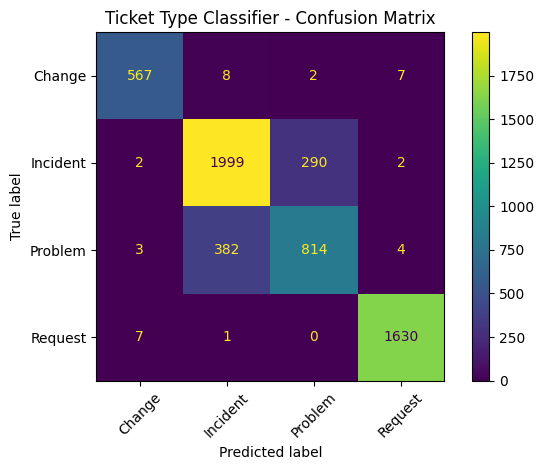

In [10]:
labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    type_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(xticks_rotation=45)
plt.title("Ticket Type Classifier - Confusion Matrix")
plt.tight_layout()
plt.savefig("../reports/type_confusion_matrix.png")
plt.show()

In [11]:
joblib.dump(best_type_model,"../models/ticket_type_baseline.pkl")

['../models/ticket_type_baseline.pkl']

In [18]:
type_model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, type_pred_LR),
        "macro_f1": f1_score(y_test, type_pred_LR, average="macro"),
        "weighted_f1": f1_score(y_test, type_pred_LR, average="weighted")
    },
    {
        "model": "LinearSVC",
        "accuracy": accuracy_score(y_test, type_pred_SVC),
        "macro_f1": f1_score(y_test, type_pred_SVC, average="macro"),
        "weighted_f1": f1_score(y_test, type_pred_SVC, average="weighted")
    },
    {
        "model": "LinearSVC + GridSearchCV",
        "accuracy": accuracy_score(y_test, type_pred),
        "macro_f1": f1_score(y_test, type_pred, average="macro"),
        "weighted_f1": f1_score(y_test, type_pred, average="weighted")
    }
])

type_model_comparison

,model,accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.840154,0.852293,0.841859
1,LinearSVC,0.868136,0.873812,0.866519
2,LinearSVC + GridSearchCV,0.876180,0.881864,0.874911


In [19]:
type_model_comparison.to_csv(
    "../reports/type_model_comparison.csv",
    index=False
)

In [12]:
type_results = test_df.copy()

type_results["actual_type"] = y_test.values
type_results["predicted_type"] = type_pred
type_results["correct_type"] = type_results["actual_type"] == type_results["predicted_type"]

wrong_type = type_results[type_results["correct_type"] == False]

wrong_type.to_csv(
    "../reports/wrong_type_predictions.csv",
    index=False
)

wrong_type[[
    "clean_text",
    "actual_type",
    "predicted_type",
    "queue",
    "language"
]].head(30)

,clean_text,actual_type,predicted_type,queue,language
2,issue encountered assistance needed,Problem,Incident,Technical Support,en
3,benötigte unterstützung bei datenintegration e...,Incident,Problem,General Inquiry,de
22,challenges in leadership for marketing agencie...,Incident,Problem,Sales and Pre-Sales,de
35,anomaly in data handling es gab eine datenverl...,Problem,Incident,Human Resources,de
39,digital advertising campaign not meeting expec...,Incident,Problem,Product Support,en
41,"geehrte kundenservice, wir melden uns bezüglic...",Problem,Incident,Customer Service,de
61,festgestellte leistungsprobleme bei digitalen ...,Problem,Incident,Returns and Exchanges,de
83,sicherheitsvorfall im krankenhaus im krankenha...,Problem,Incident,Technical Support,de
111,support for service disruptions dear customer ...,Problem,Incident,Service Outages and Maintenance,de
128,concerns with application connectivity dear cu...,Problem,Incident,Service Outages and Maintenance,en


In [13]:
problem_incident_errors = wrong_type[
    (
        (wrong_type["actual_type"] == "Problem") &
        (wrong_type["predicted_type"] == "Incident")
    )
    |
    (
        (wrong_type["actual_type"] == "Incident") &
        (wrong_type["predicted_type"] == "Problem")
    )
]

problem_incident_errors[[
    "clean_text",
    "actual_type",
    "predicted_type",
    "queue",
    "language"
]].head(30)

,clean_text,actual_type,predicted_type,queue,language
2,issue encountered assistance needed,Problem,Incident,Technical Support,en
3,benötigte unterstützung bei datenintegration e...,Incident,Problem,General Inquiry,de
22,challenges in leadership for marketing agencie...,Incident,Problem,Sales and Pre-Sales,de
35,anomaly in data handling es gab eine datenverl...,Problem,Incident,Human Resources,de
39,digital advertising campaign not meeting expec...,Incident,Problem,Product Support,en
41,"geehrte kundenservice, wir melden uns bezüglic...",Problem,Incident,Customer Service,de
61,festgestellte leistungsprobleme bei digitalen ...,Problem,Incident,Returns and Exchanges,de
83,sicherheitsvorfall im krankenhaus im krankenha...,Problem,Incident,Technical Support,de
111,support for service disruptions dear customer ...,Problem,Incident,Service Outages and Maintenance,de
128,concerns with application connectivity dear cu...,Problem,Incident,Service Outages and Maintenance,en


In [14]:
problem_incident_errors.to_csv("../reports/problem_incident_confusion.csv",index=False)

## Language-wise Evaluation

In [20]:
type_lang_rows = []

type_results = test_df.copy()
type_results["actual_type"] = y_test.values
type_results["predicted_type"] = type_pred

for lang in sorted(type_results["language"].unique()):
    temp = type_results[type_results["language"] == lang]

    report = classification_report(
        temp["actual_type"],
        temp["predicted_type"],
        output_dict=True,
        zero_division=0
    )

    type_lang_rows.append({
        "language": lang,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    })

type_language_metrics = pd.DataFrame(type_lang_rows)

type_language_metrics.to_csv(
    "../reports/type_language_metrics.csv",
    index=False
)

type_language_metrics

,language,accuracy,macro_f1,weighted_f1
0,de,0.831126,0.838350,0.829227
1,en,0.909146,0.913901,0.908265
